# Minimizando o Makespan em um Job-Shop com PROC OPTMODEL


## Sumário Executivo

Uma pequena célula de manufatura discreta precisa fazer quatro peças passarem — um **Suporte**, um **Flange**, uma **Carcaça** e um **Eixo** — por uma sequência fixa de três operações de usinagem cada, compartilhando quatro máquinas de capacidade unitária (**Serra**, **Fresa**, **Furadeira**, **Retífica**). Nenhuma máquina pode executar duas operações ao mesmo tempo, e as operações de cada peça devem seguir sua ordem tecnológica. Formulamos a programação que minimiza o makespan como um programa inteiro misto no **PROC OPTMODEL** — variáveis de tempo de início, restrições de precedência fim-para-início e restrições disjuntivas (big-*M*) de não sobreposição entre cada par de operações que compartilham uma máquina — e o resolvemos até a otimalidade comprovada.

O solver MILP retorna um **makespan ótimo de 120 minutos** (`Solution Status = Optimal`, `Objective Value = 120`). A programação resultante encaixa todas as doze operações de modo que cada máquina processe no máximo uma peça por vez e cada peça seja usinada na ordem exigida, com a Retífica sempre por último quando presente. Duas operações terminam exatamente no minuto 120 — a retificação do Suporte e o fresamento da Carcaça — de modo que tanto a máquina Retífica quanto a Fresa estão no caminho crítico que fixa a duração da programação.

## Fontes de Dados

Todos os dados são definidos dentro do notebook — sem arquivos externos ou rede.

| Conjunto de dados | Linhas | Variáveis-chave | Descrição |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Uma linha por operação (4 peças × 3 operações). `machine` (1–4) é a máquina de que a operação precisa; `dur` é seu tempo de processamento em minutos; `jobname`/`mname` são rótulos legíveis de peça e máquina. |
| `sched` | 12 | `op`, `start`, `finish` | Saída do OPTMODEL: o minuto ótimo de início e término de cada operação. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` mesclado com os tempos resolvidos, ordenado por máquina e depois por início — a programação legível por humanos. |
| `mk` | 1 | `makespan` | O makespan realizado (último tempo de término). |

## O problema de programação

Em um **job shop**, várias peças ("jobs") passam cada uma por uma sequência fixa de operações, e cada operação é executada em uma máquina específica. Duas operações não podem ocupar a mesma máquina ao mesmo tempo (as máquinas são recursos *unários*), e dentro de uma peça as operações devem respeitar sua ordem tecnológica. O planejador quer tempos de início para cada operação que respeitem ambas as regras, mantendo a duração total da programação — o **makespan** — o menor possível.

Este é um problema clássico de programação disjuntiva. Nós o modelamos como um programa inteiro misto:

- um **tempo de início** contínuo-mas-inteiro `s[o]` para cada operação, e uma variável de makespan `Cmax`;
- **precedência**: a operação *k+1* de uma peça começa não antes de a operação *k* terminar;
- **capacidade disjuntiva de máquina**: para cada par de operações que compartilham uma máquina, um binário `y` decide qual vai primeiro, e um termo big-*M* desliga a ordenação inativa — de modo que as duas operações nunca possam se sobrepor;
- **objetivo**: minimizar `Cmax`, que é forçado a ser pelo menos o tempo de término de cada operação.

O PROC OPTMODEL é o procedimento de modelagem algébrica do SAS/OR; seu solver MILP encontra a programação mais curta *comprovadamente ótima*.

> **Uma nota sobre o PROC CLP.** O SAS também oferece o PROC CLP, um mecanismo de > programação lógica por restrições com sintaxe de programação dedicada (atividades, > recursos, precedência). A formulação MILP do OPTMODEL aqui resolve o > problema idêntico e retorna um certificado de otimalidade, o que a > busca por viabilidade do CLP não faz.

## Passo 1 — Definir a instância do shop

Quatro peças, três operações cada, em quatro máquinas. Cada linha fixa a máquina de que uma operação precisa e seu tempo de processamento em minutos. As operações de uma peça são listadas em ordem tecnológica (`opnum` 1, 2, 3).

In [1]:
DADOS jobshop;
    COMPRIMENTO jobname $12 mname $12;
    ENTRADA op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Suporte  Serra
2  1 2 3 40 Suporte  Furadeira
3  1 3 4 20 Suporte  Retífica
4  2 1 2 35 Flange   Fresa
5  2 2 3 25 Flange   Furadeira
6  2 3 1 15 Flange   Serra
7  3 1 3 30 Carcaça  Furadeira
8  3 2 1 20 Carcaça  Serra
9  3 3 2 45 Carcaça  Fresa
10 4 1 1 20 Eixo     Serra
11 4 2 2 30 Eixo     Fresa
12 4 3 4 25 Eixo     Retífica
;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=jobshop noobs RÓTULO;
    TÍTULO "Instância do job-shop: 4 peças, 3 operações cada, 4 máquinas";
    VARIÁVEL op jobname opnum mname dur;
    RÓTULO op="Op" jobname="Peça" opnum="Nº op" mname="Máquina" dur="Duração (min)";
EXECUTAR;

                              Instância do job-shop: 4 peças, 3 operações cada, 4 máquinas                              

Op      Peça   Nº op    Máquina    Duração (min)
 1  Suporte        1  Serra                   25
 2  Suporte        2  Furadeira               40
 3  Suporte        3  Retífica                20
 4  Flange         1  Fresa                   35
 5  Flange         2  Furadeira               25
 6  Flange         3  Serra                   15
 7  Carcaça        1  Furadeira               30
 8  Carcaça        2  Serra                   20
 9  Carcaça        3  Fresa                   45
10  Eixo           1  Serra                   20
11  Eixo           2  Fresa                   30
12  Eixo           3  Retífica                25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Passo 2 — Resolver a programação que minimiza o makespan com o PROC OPTMODEL

O OPTMODEL lê a instância, constrói as variáveis de tempo de início e de ordenação, posta as restrições de precedência e disjuntivas, e minimiza o makespan com seu solver MILP. O horizonte big-*M* `H` é o conteúdo total de trabalho — um limite superior seguro para qualquer tempo de início. O solver reporta o objetivo **ótimo**; escrevemos os tempos de início e término escolhidos em `sched`.

In [2]:
PROCEDIMENTO optmodel;
    DEFINIR OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ DADOS jobshop INTO OPS=[op] job opnum machine dur;

    /* horizonte big-M seguro = conteúdo total de trabalho */
    num H = sum{o IN OPS} dur[o];

    VARIÁVEL s{OPS} >= 0 integer;     /* tempo de início da operação (minutos) */
    VARIÁVEL Cmax >= 0;               /* makespan */

    /* ordem tecnológica: a op k+1 começa após a op k terminar */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] E_LÓGICO opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* o makespan domina o tempo de término de cada operação */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* capacidade disjuntiva de máquina: para cada par de operações que
       compartilham uma máquina, o binário y fixa a ordem; o big-M relaxa o outro */
    VARIÁVEL y{a IN OPS, b IN OPS:
          a < b E_LÓGICO machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b E_LÓGICO machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b E_LÓGICO machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CRIAR DADOS sched DE_TABELA
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                              Instância do job-shop: 4 peças, 3 operações cada, 4 máquinas                              


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Passo 3 — Montar a programação legível

Mescle os tempos resolvidos de volta aos rótulos de peça e máquina, ordene por máquina e depois por tempo de início, e imprima a programação. O makespan é o maior tempo de término entre todas as operações.

In [3]:
PROCEDIMENTO ORDENAR DADOS=jobshop out=jobs2; POR op; EXECUTAR;
PROCEDIMENTO ORDENAR DADOS=sched   out=sol;   POR op; EXECUTAR;

DADOS schedule;
    MESCLAR jobs2 sol;
    POR op;
EXECUTAR;

PROCEDIMENTO ORDENAR DADOS=schedule; POR mname START; EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=schedule noobs RÓTULO;
    TÍTULO "Programação ótima: início / término (minutos) de cada operação";
    VARIÁVEL jobname opnum mname dur START FINISH;
    RÓTULO jobname="Peça" opnum="Nº op" mname="Máquina" dur="Duração (min)"
           START="Início" FINISH="Término";
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=schedule MAX NOPRINT;
    VARIÁVEL FINISH;
    SAÍDA out=mk(REMOVER=_type_ _freq_) MAX=makespan;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=mk noobs RÓTULO;
    TÍTULO "Makespan mínimo (último término de operação, minutos)";
    RÓTULO makespan="Makespan (min)";
EXECUTAR;

                             Programação ótima: início / término (minutos) de cada operação                             

    Peça   Nº op    Máquina    Duração (min)   Início   Término
Flange         1  Fresa                   35        0        35
Eixo           2  Fresa                   30       35        65
Carcaça        3  Fresa                   45       75       120
Carcaça        1  Furadeira               30        0        30
Flange         2  Furadeira               25       35        60
Suporte        2  Furadeira               40       60       100
Eixo           3  Retífica                25       65        90
Suporte        3  Retífica                20      100       120
Eixo           1  Serra                   20        0        20
Suporte        1  Serra                   25       20        45
Carcaça        2  Serra                   20       45        65
Flange         3  Serra                   15       65        80

                                 Makespan mín


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Passo 4 — Visualizar a programação

Damos a cada operação um **slot** ordinal (ordenado por máquina e depois por início) e desenhamos sua janela de tempo como uma barra flutuante: a barra vai do minuto de início da operação ao seu minuto de término. Os slots 1–3 são a Fresa, 4–6 a Furadeira, 7–8 a Retífica e 9–12 a Serra. A tabela logo abaixo nomeia a peça em cada slot, de modo que o gráfico e a tabela sejam lidos em conjunto. Barras na mesma máquina nunca se sobrepõem no tempo — a restrição disjuntiva tornada visível.

                         Programação por slot (a ordem dos slots corresponde ao gráfico abaixo)                         

Slot    Máquina      Peça   Início   Término
   1  Fresa      Flange          0        35
   2  Fresa      Eixo           35        65
   3  Fresa      Carcaça        75       120
   4  Furadeira  Carcaça         0        30
   5  Furadeira  Flange         35        60
   6  Furadeira  Suporte        60       100
   7  Retífica   Eixo           65        90
   8  Retífica   Suporte       100       120
   9  Serra      Eixo            0        20
  10  Serra      Suporte        20        45
  11  Serra      Carcaça        45        65
  12  Serra      Flange         65        80

                         Programação por slot (a ordem dos slots corresponde ao gráfico abaixo)                         




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


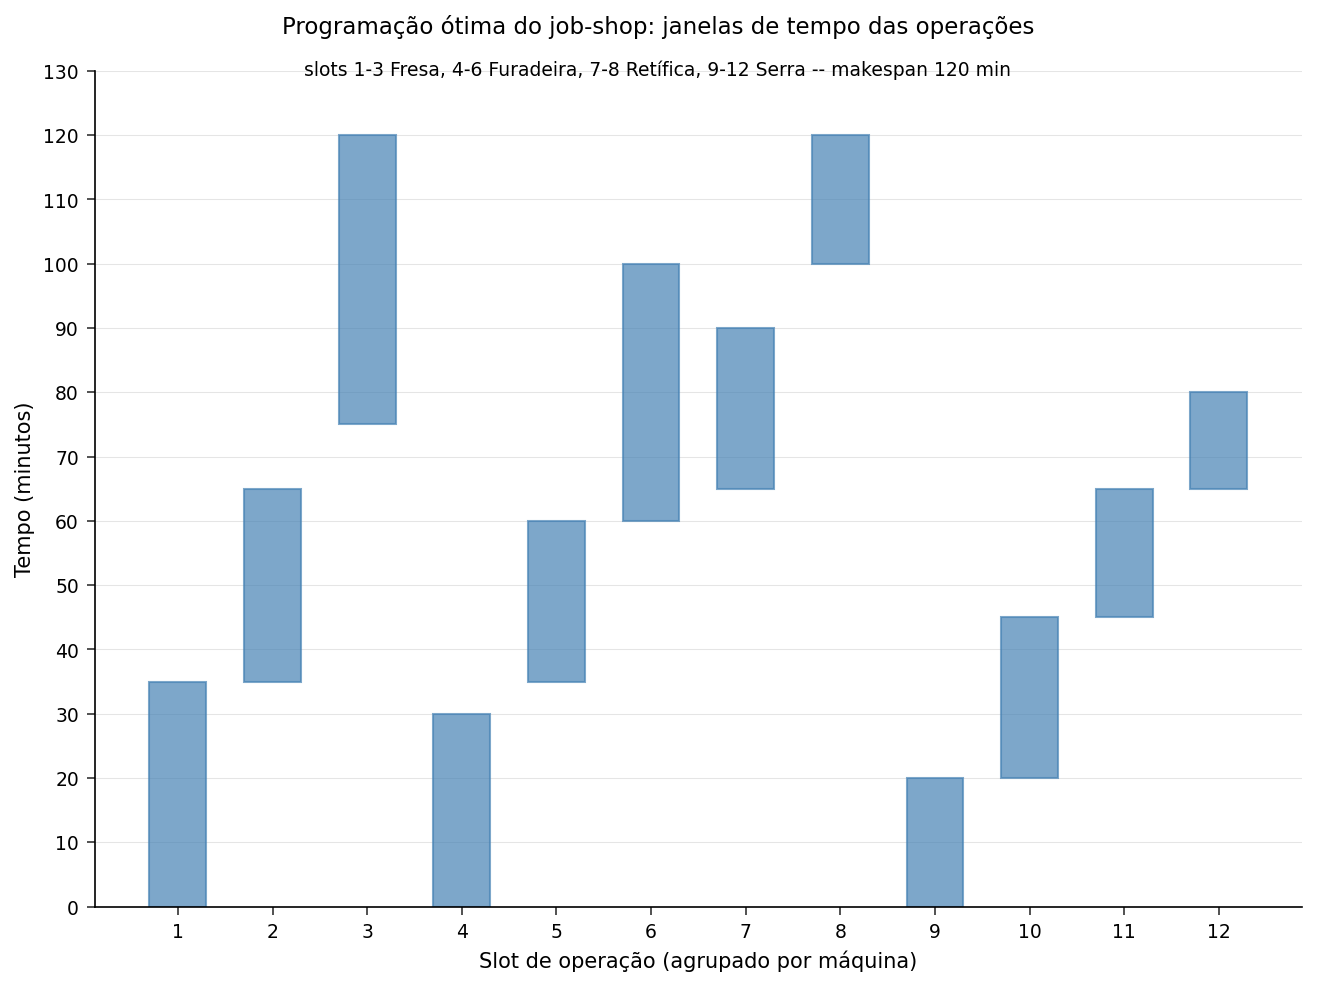

In [4]:
DADOS ganttdata;
    DEFINIR schedule;
    slot + 1;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=ganttdata noobs RÓTULO;
    TÍTULO "Programação por slot (a ordem dos slots corresponde ao gráfico abaixo)";
    VARIÁVEL slot mname jobname START FINISH;
    RÓTULO slot="Slot" mname="Máquina" jobname="Peça" START="Início" FINISH="Término";
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=ganttdata noautolegend;
    TÍTULO "Programação ótima do job-shop: janelas de tempo das operações";
    title2 "slots 1-3 Fresa, 4-6 Furadeira, 7-8 Retífica, 9-12 Serra -- makespan 120 min";
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS RÓTULO="Slot de operação (agrupado por máquina)" integer
          VALUES=(1 ATÉ 12 POR 1);
    YAXIS RÓTULO="Tempo (minutos)" grid VALUES=(0 ATÉ 130 POR 10);
EXECUTAR;
TÍTULO;

## Interpretando os resultados

- **Otimalidade.** O solver MILP retornou `Solution Status = Optimal` com `Objective Value = 120`, portanto **120 minutos é o menor makespan comprovadamente possível** para esta instância — nenhuma programação pode terminar antes. Esse certificado é o que a formulação de programação matemática lhe dá em relação a uma busca puramente por viabilidade.

- **A programação respeita todas as restrições.** Lendo a tabela por máquina, nenhuma dupla de operações na mesma máquina se sobrepõe (por exemplo, na Serra: Eixo 0–20, Suporte 20–45, Carcaça 45–65, Flange 65–80), e cada peça é executada em ordem tecnológica (por exemplo, Carcaça: Furadeira 0–30, depois Serra 45–65, depois Fresa 75–120). O gráfico de barras flutuantes mostra o mesmo: dentro da faixa de slots de cada máquina, as janelas de tempo se encaixam sem colisão.

- **O que define a duração da programação.** Duas operações terminam exatamente no minuto 120 — a Retífica do Suporte (slot 8) e a Fresa da Carcaça (slot 3). Ambas tocam o makespan, de modo que as máquinas Retífica e Fresa ficam no caminho crítico; reduzir ainda mais o makespan exigiria mudar a própria instância (operações mais rápidas, uma máquina extra ou precedência relaxada), e não apenas reordenar.

- **Como isso escala.** A formulação cresce naturalmente: adicione uma máquina como outro valor de `machine`, adicione peças como mais linhas de `jobshop`, ou modele datas de liberação e de entrega limitando `s[o]` e adicionando restrições de prazo. Permitir que uma máquina execute vários jobs ao mesmo tempo (capacidade >1) substitui a disjunção par a par por uma restrição de recurso cumulativo. O mesmo MILP do OPTMODEL então lida com regras de chão de fábrica mais ricas sem mudar o solver.